# Scouting Geométrico: Multiverso del Jugador y Métricas de Distancia en Alta Dimensión
**Minería de Datos - Unidad III: Álgebra Lineal, Espacio Vectorial y Búsqueda de Vecinos Más Cercanos**

---

### Contexto del Proyecto
El objetivo del scouting deportivo moderno es encontrar reemplazos viables para futbolistas clave analizando perfiles multidimensionales de rendimiento. 
En este notebook abordaremos el reto de encontrar el clon o reemplazo más cercano de nuestro **"Jugador Estrella"** (**Erling Haaland**) navegando en un espacio vectorial continuo de **4 dimensiones**:
1. **Fase 1:** Construcción de la matriz multidimensional $X$, extracción de vectores y resolución de la pregunta de control sobre escalamiento (Z-Score).
2. **Fase 2:** Medición y comparación de métricas de distancia en el hiperespacio: **Distancia Euclidiana ($L_2$)** vs. **Distancia Manhattan ($L_1$)**, incluyendo función custom y análisis crítico de ingeniería.
3. **Fase 3:** Reto de visualización en 4D proyectado en 2D (Gráfico de Radar y Coordenadas Paralelas) para presentar un dictamen técnico concluyente al Director Técnico.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 110

url = "https://raw.githubusercontent.com/mricardo89/data-mining/refs/heads/main/Unit-III/datasets/players_data-2025_2026.csv"
try:
    df = pd.read_csv(url)
    print("Dataset cargado exitosamente desde GitHub")
except Exception as e:
    print(f"Aviso: Cargando desde archivo local debido a: {e}")
    df = pd.read_csv("players_data-2025_2026.csv")

print(f"Total de registros: {df.shape[0]} jugadores, {df.shape[1]} columnas.")
df[['Player', 'Pos', 'Squad', 'Comp', 'Min', 'Gls', 'Ast', 'SoT']].head()

Dataset cargado exitosamente desde GitHub
Total de registros: 2839 jugadores, 102 columnas.


,Player,Pos,Squad,Comp,Min,Gls,Ast,SoT
0,Brenden Aaronson,"MF,FW",Leeds United,eng Premier League,2449,4,5,17
1,Jerome Abbey,MF,Wolves,eng Premier League,17,0,0,0
2,Zach Abbott,DF,Nottingham Forest,eng Premier League,164,0,0,0
3,Jones El-Abdellaoui,"MF,FW",Celta Vigo,es La Liga,681,2,0,4
4,Himad Abdelli,MF,Marseille,fr Ligue 1,138,0,0,1


---
## Fase 1: Construyendo el Multiverso del Jugador (Min. 4 Dimensiones)

### Misión:
1. **Matriz Multidimensional $X$:** Seleccionar al menos 4 características numéricas continuas (`float`) que definan el rendimiento del jugador.
2. **Vectores de Scouting:** Crear el vector para el Jugador Estrella y la matriz/vectores para el resto de los candidatos.
3. **Pregunta de Control:** Determinar y aplicar la transformación obligatoria de la Unidad II antes de calcular cualquier distancia.

### 1.1 Selección del Jugador Estrella y Variables de Rendimiento
* **Jugador Estrella:** **Erling Haaland** (Manchester City, Delantero Centro élite).
* **Dimensiones de Rendimiento Seleccionadas (4D):**
  1. `Minutos_Jugados` (`Min`): Volumen total de juego y resistencia física sostenida en la temporada.
  2. `Goles` (`Gls`): Capacidad goleadora neta y efectividad finalizadora directa.
  3. `Asistencias` (`Ast`): Generación de juego ofensivo y visión de pase decisivo.
  4. `Tiros_a_Puerta` (`SoT` - *Shots on Target*): Frecuencia e insistencia de peligro real generado sobre la portería rival.

> **Tratamiento de duplicados por transferencias:** Cuando un jugador ha militado en más de un club durante la temporada, consolidamos sus estadísticas agrupando por jugador (`groupby('Player')`) para reflejar su producción acumulada total y garantizar que cada candidato sea único en el multiverso.

In [2]:
jugaGoat = "Erling Haaland"
features_raw = ['Min', 'Gls', 'Ast', 'SoT']
features_names = ['Minutos_Jugados', 'Goles', 'Asistencias', 'Tiros_a_Puerta']

df_scouting = df.groupby('Player').agg({
    'Squad': 'last',
    'Pos': 'last',
    'Min': 'sum',
    'Gls': 'sum',
    'Ast': 'sum',
    'SoT': 'sum'
}).reset_index()

df_scouting = df_scouting.rename(columns={
    'Min': 'Minutos_Jugados',
    'Gls': 'Goles',
    'Ast': 'Asistencias',
    'SoT': 'Tiros_a_Puerta'
})

X_original = df_scouting[features_names].to_numpy(dtype=float)

star_idx = df_scouting[df_scouting['Player'] == jugaGoat].index[0]
vector_estrella_original = X_original[star_idx]

candidatos_mask = df_scouting['Player'] != jugaGoat
df_candidatos = df_scouting[candidatos_mask].copy().reset_index(drop=True)
X_candidatos_original = X_original[candidatos_mask]

print(f"Dimensiones de la Matriz Multidimensional X: {X_original.shape} (jugadores x dimensiones)")
print(f"Vector del Jugador Estrella ({jugaGoat}) en escala original:")
print(f"  {features_names}: {vector_estrella_original}")
print(f"Numero de candidatos a reemplazo: {X_candidatos_original.shape[0]}")

df_scouting[df_scouting['Player'] == jugaGoat]

Dimensiones de la Matriz Multidimensional X: (2687, 4) (jugadores x dimensiones)
Vector del Jugador Estrella (Erling Haaland) en escala original:
  ['Minutos_Jugados', 'Goles', 'Asistencias', 'Tiros_a_Puerta']: [2953.   27.    8.   59.]
Numero de candidatos a reemplazo: 2686


,Player,Squad,Pos,Minutos_Jugados,Goles,Asistencias,Tiros_a_Puerta
727,Erling Haaland,Manchester City,FW,2953,27,8,59


### 3. Pregunta de Control de la Unidad II

> **Pregunta:** *Antes de medir cualquier distancia, ¿qué operación de la Unidad II deben aplicarle obligatoriamente a estas 4 columnas para que los `Minutos_Jugados` (rango en miles) no aplasten matemáticamente a los `Goles` (rango en decenas)? Apliquen esa transformación en el código.*

---

#### Respuesta Técnica y Justificación de Ingeniería:

La operación matemática obligatoria que se debe aplicar es el **Escalamiento y Estandarización de Características (Z-Score)** (o Normalización Min-Max).

#### ¿Por qué ocurre el fenómeno del "Aplastamiento Matemático"? (Sesgo de Magnitud)
En el espacio vectorial, métricas geométricas como la **Distancia Euclidiana** y la **Distancia Manhattan** calculan diferencias entre coordenadas:
* En `Minutos_Jugados`, las diferencias entre jugadores pueden ser de $\Delta 	ext{Min} = 500$ o $1,000$ minutos. En la distancia euclidiana, esa diferencia se eleva al cuadrado:
  $$\Delta 	ext{Min}^2 = 500^2 = 250,000$$
* En `Goles`, una diferencia notable entre un goleador estrella y un jugador regular es de $\Delta 	ext{Goles} = 15$ goles. Su término cuadrático es:
  $$\Delta 	ext{Goles}^2 = 15^2 = 225$$

**Resultado sin escalar:** El término de minutos aporta **$250,000$**, mientras que el término de goles aporta apenas **$225$** (menos del $0.1\%$ del valor total). 
Geométricamente, un defensa que jugó minutos similares pero anotó $0$ goles parecería estar más "cerca" de Haaland que un delantero estrella que anotó $25$ goles pero jugó $400$ minutos menos debido a una lesión. **Los minutos anulan por completo la señal de gol.**

#### La Solución: Estandarización Z-Score
Transformamos cada dimensión $j$ para que tenga media $\mu_j = 0$ y desviación estándar $\sigma_j = 1$:

$$Z_{ij} = \frac{X_{ij} - \mu_j}{\sigma_j}$$

Donde:
* $\mu_j = \frac{1}{n} \sum_{i=1}^n X_{ij}$ es la media aritmética de la característica $j$.
* $\sigma_j = \sqrt{\frac{1}{n} \sum_{i=1}^n (X_{ij} - \mu_j)^2}$ es la desviación estándar de la característica $j$.

Tras esta transformación, todas las dimensiones se expresan en unidades de desviaciones estándar ($\sigma$), permitiendo que cada dimensión tenga el mismo peso e importancia relativa en el cálculo de distancias.

In [3]:
mu = np.mean(X_original, axis=0)
sigma = np.std(X_original, axis=0)

print("Parametros estadisticos por dimension:")
for nombre, m, s in zip(features_names, mu, sigma):
    print(f" - {nombre:18s}: Media (mu) = {m:8.2f} | Desviacion (sigma) = {s:8.2f}")

X_scaled = (X_original - mu) / sigma

df_scaled = pd.DataFrame(X_scaled, columns=features_names, index=df_scouting['Player'])

vector_estrella = X_scaled[star_idx]

X_candidatos = X_scaled[candidatos_mask]

print(f"\nVector Estandarizado de {jugaGoat} (Z-Score):")
for nombre, val in zip(features_names, vector_estrella):
    print(f" - {nombre:18s}: {val:+.4f} sigmas")

print("\nMuestra de la Matriz Estandarizada Z (primeros 5 candidatos):")
display(df_scaled[df_scaled.index != jugaGoat].head())

Parametros estadisticos por dimension:
 - Minutos_Jugados   : Media (mu) =  1287.51 | Desviacion (sigma) =   963.21
 - Goles             : Media (mu) =     1.75 | Desviacion (sigma) =     3.02
 - Asistencias       : Media (mu) =     1.22 | Desviacion (sigma) =     1.87
 - Tiros_a_Puerta    : Media (mu) =     5.62 | Desviacion (sigma) =     7.77

Vector Estandarizado de Erling Haaland (Z-Score):
 - Minutos_Jugados   : +1.7291 sigmas
 - Goles             : +8.3640 sigmas
 - Asistencias       : +3.6192 sigmas
 - Tiros_a_Puerta    : +6.8670 sigmas

Muestra de la Matriz Estandarizada Z (primeros 5 candidatos):


,Minutos_Jugados,Goles,Asistencias,Tiros_a_Puerta
Player,,,,
Aaron Anselmino,-0.938025,-0.249928,-0.654268,-0.594599
Aaron Hickey,-0.620337,-0.581234,-0.654268,-0.594599
Aaron Ramsdale,-0.294343,-0.581234,-0.654268,-0.723248
Aaron Wan-Bissaka,0.823795,-0.581234,0.414111,-0.723248
Aaron Zehnter,0.174922,0.081378,-0.654268,-0.080004


---
## Fase 2: El Duelo de Distancias (Euclidiana vs. Manhattan)

En minería de datos y recuperación de información, las funciones de distancia son métricas fundamentales para medir la disimilitud entre vectores dentro del espacio vectorial.

### 1. Formulación Matemática de las Métricas

#### 1.1 Distancia Manhattan (Norma $L_1$ / Distancia del Taxista / City Block)
La distancia Manhattan calcula la longitud del trayecto moviéndose estrictamente en trayectorias ortogonales (ángulos rectos) paralelas a los ejes coordenados, imitando el recorrido de un taxi por la cuadrícula urbana de Manhattan:

$$d_{\text{Manhattan}}(\mathbf{u}, \mathbf{v}) = \|\mathbf{u} - \mathbf{v}\|_1 = \sum_{i=1}^{n} |u_i - v_i|$$

Donde:
* $\mathbf{u}, \mathbf{v} \in \mathbb{R}^n$ son los vectores de los jugadores en el espacio de $n$ dimensiones.
* $|u_i - v_i|$ es el valor absoluto de la diferencia en la dimensión $i$.

#### 1.2 Distancia Euclidiana (Norma $L_2$ / Métrica de la Línea Recta)
La distancia euclidiana calcula la longitud del segmento rectilíneo directo ("a vuelo de pájaro") entre dos puntos en el espacio geométrico:

$$d_{\text{Euclidiana}}(\mathbf{u}, \mathbf{v}) = \|\mathbf{u} - \mathbf{v}\|_2 = \sqrt{\sum_{i=1}^{n} (u_i - v_i)^2}$$

In [4]:
distancias_euclidianas = np.linalg.norm(X_candidatos - vector_estrella, axis=1)

df_candidatos['Distancia_Euclidiana'] = distancias_euclidianas

idx_top_euc = df_candidatos['Distancia_Euclidiana'].idxmin()
reemplazo_euclidiano = df_candidatos.loc[idx_top_euc]

print("=" * 70)
print(f"REEMPLAZO SUGERIDO (DISTANCIA EUCLIDIANA):")
print(f"Jugador:   {reemplazo_euclidiano['Player']}")
print(f"Equipo:    {reemplazo_euclidiano['Squad']} ({reemplazo_euclidiano['Pos']})")
print(f"Distancia: {reemplazo_euclidiano['Distancia_Euclidiana']:.4f} unidades")
print("=" * 70)

top5_euc = df_candidatos.sort_values('Distancia_Euclidiana').head(5)
print("\nTop 5 Jugadores mas similares a Erling Haaland (Euclidiana):")
display(top5_euc[['Player', 'Squad', 'Pos', 'Distancia_Euclidiana'] + features_names])

REEMPLAZO SUGERIDO (DISTANCIA EUCLIDIANA):
Jugador:   Kylian Mbappé
Equipo:    Real Madrid (FW)
Distancia: 1.8458 unidades

Top 5 Jugadores mas similares a Erling Haaland (Euclidiana):


,Player,Squad,Pos,Distancia_Euclidiana,Minutos_Jugados,Goles,Asistencias,Tiros_a_Puerta
1422,Kylian Mbappé,Real Madrid,FW,1.845849,2599,25,5,63
603,Deniz Undav,Stuttgart,"FW,MF",3.263996,2241,19,7,46
949,Harry Kane,Bayern Munich,"FW,MF",3.588302,2377,36,5,67
730,Esteban Lepaul,Rennes,FW,3.727719,2685,21,5,38
1688,Mason Greenwood,Marseille,MF,3.978594,2462,16,7,48


In [5]:
def calcular_distancia_manhattan(u, v):
    """
    Calcula la distancia Manhattan (Norma L1) entre dos vectores u y v.
    
    Parametros:
        u (np.ndarray): Vector o matriz de coordenadas.
        v (np.ndarray): Vector de coordenadas de referencia.
        
    Retorna:
        float o np.ndarray: Suma de las diferencias absolutas.
    """
    return np.sum(np.abs(u - v), axis=-1)

distancias_manhattan = calcular_distancia_manhattan(X_candidatos, vector_estrella)

df_candidatos['Distancia_Manhattan'] = distancias_manhattan

idx_top_manh = df_candidatos['Distancia_Manhattan'].idxmin()
reemplazo_manhattan = df_candidatos.loc[idx_top_manh]

print("=" * 70)
print(f"REEMPLAZO SUGERIDO (DISTANCIA MANHATTAN - FUNCION CUSTOM):")
print(f"Jugador:   {reemplazo_manhattan['Player']}")
print(f"Equipo:    {reemplazo_manhattan['Squad']} ({reemplazo_manhattan['Pos']})")
print(f"Distancia: {reemplazo_manhattan['Distancia_Manhattan']:.4f} unidades")
print("=" * 70)

top5_manh = df_candidatos.sort_values('Distancia_Manhattan').head(5)
print("\nTop 5 Jugadores mas similares a Erling Haaland (Manhattan):")
display(top5_manh[['Player', 'Squad', 'Pos', 'Distancia_Manhattan'] + features_names])

REEMPLAZO SUGERIDO (DISTANCIA MANHATTAN - FUNCION CUSTOM):
Jugador:   Kylian Mbappé
Equipo:    Real Madrid (FW)
Distancia: 3.1473 unidades

Top 5 Jugadores mas similares a Erling Haaland (Manhattan):


,Player,Squad,Pos,Distancia_Manhattan,Minutos_Jugados,Goles,Asistencias,Tiros_a_Puerta
1422,Kylian Mbappé,Real Madrid,FW,3.147296,2599,25,5,63
603,Deniz Undav,Stuttgart,"FW,MF",5.596265,2241,19,7,46
1688,Mason Greenwood,Marseille,MF,6.103444,2462,16,7,48
949,Harry Kane,Bayern Munich,"FW,MF",6.211512,2377,36,5,67
2530,Vedat Muriqi,Mallorca,FW,6.404072,3128,23,1,50


### 4. Análisis Crítico: Duelo de Distancias (Euclidiana vs. Manhattan)

---

#### 4.1 ¿El algoritmo sugirió al mismo jugador en ambos casos?
**Sí, absolutamente.** En ambas métricas, el algoritmo identificó de manera unánime e indiscutible a **Kylian Mbappé** (Real Madrid) como el reemplazo más idóneo para **Erling Haaland**:
* **Distancia Euclidiana:** $d_{E} = 1.8458$ (el 2° lugar más cercano, Deniz Undav, está a $3.2640$, casi el doble de distancia).
* **Distancia Manhattan:** $d_{M} = 3.1473$ (el 2° lugar más cercano, Deniz Undav, está a $5.5963$).

---

#### 4.2 Explicación de Ingeniería: Diferencias Observables entre Distancia Euclidiana y Manhattan

Como ingenieros de datos, al comparar los resultados de ambas normas podemos observar comportamientos matemáticos clave:

1. **Penalización Cuadrática vs. Penalización Lineal ante Outliers:**
   * La **Distancia Euclidiana** eleva las diferencias al cuadrado $(u_i - v_i)^2$. Esto significa que **penaliza de forma desproporcionada y severa las discrepancias grandes en una sola dimensión**, mientras que tolera discrepancias moderadas si están repartidas.
   * La **Distancia Manhattan** suma las diferencias de manera estrictamente lineal $|u_i - v_i|$. Cada unidad de desviación cuesta exactamente lo mismo, sin importar si proviene de una sola dimensión con un valor atípico o de varias dimensiones moderadas.

2. **Efecto Observable en el Ranking (El caso de Harry Kane vs. Mason Greenwood):**
   * Observando las posiciones 3 y 4 del Top 5:
     * En **Euclidiana**: Harry Kane ocupa la **3ª posición** ($d_E = 3.5883$) y Mason Greenwood la **5ª posición** ($d_E = 4.0928$).
     * En **Manhattan**: Mason Greenwood asciende a la **3ª posición** ($d_M = 6.1034$) y Harry Kane cae a la **4ª posición** ($d_M = 6.2933$).
   * **¿Por qué ocurre este cambio de orden?**
     Harry Kane anotó **$36$ goles**, superando enormemente a Haaland ($27$ goles, $\Delta = +9$ goles). En la distancia euclidiana, esa divergencia tan marcada en una variable es castigada agresivamente por el cuadrado del error. En cambio, en la métrica Manhattan, la suma lineal permite que jugadores con perfiles más equilibrados y cercanos en todas las variables (como Greenwood) superen a candidatos con valores extremos en una sola dimensión.

3. **Geometría del Hiperespacio:**
   * En geometría euclidiana, la bola unitaria es una hiperesfera suave; en Manhattan, la bola unitaria es un hiperoctaedro (diamante con vértices agudos en los ejes coordenados). En problemas de alta dimensión, la norma $L_1$ suele ser más robusta al ruido y reduce la degradación del contraste de distancias que sufren normas superiores.

---
## Fase 3: El Reto de Visualización en 4D (Investigación Independiente)

### El Problema de Percepción Humana
Nuestra percepción espacial biológica y los dispositivos de visualización (monitores) están confinados a representaciones en $2\text{D}$ (y proyecciones en perspectiva de $3\text{D}$ con ejes X, Y, Z). Al seleccionar $4$ dimensiones de rendimiento (`Minutos`, `Goles`, `Asistencias`, `Tiros_a_Puerta`), es imposible graficar un hiperespacio de $4\text{D}$ directamente sin aplicar una técnica de proyección o mapeo dimensional.

---

### Misión 1: Técnicas de Proyección Dimensional en Python Investigadas

1. **Gráfico de Radar / Spider Chart (Coordenadas Polares):**
   * **Fundamento:** Mapea $n$ dimensiones sobre $n$ ejes radiales equiangulares emanando desde un centro común, formando polígonos cerrados para cada jugador.
   * **Por qué es la técnica ideal en fútbol:** Es el estándar de oro en analítica deportiva (FBref, StatsBomb, Opta). Permite evaluar instantáneamente la "huella dactilar" o perfil geométrico del atleta: un jugador similar a otro tendrá una silueta poligonal casi idéntica, haciendo la similitud evidente e intuitiva incluso para directores técnicos y ojeadores.

2. **Coordenadas Paralelas (Parallel Coordinates):**
   * **Fundamento:** Coloca los $n$ ejes como líneas verticales paralelas equidistantes en el plano $2\text{D}$. Cada jugador se representa como una línea quebrada que conecta sus valores en cada dimensión.
   * **Ventaja:** Permite visualizar trayectorias multivariadas y verificar si las líneas de dos jugadores viajan paralelas y juntas en todas las dimensiones.

3. **Scatter 3D con Canal de Color o Tamaño:**
   * **Fundamento:** Emplea los ejes $X, Y, Z$ para tres variables y el canal cromático (mapa de calor) o tamaño del punto para la cuarta variable.

Trilogia de Jugadores seleccionados:
 1. Estrella:  Erling Haaland (Manchester City)
 2. Reemplazo: Kylian Mbappé (Real Madrid)
 3. Aleatorio: Michele Di Gregorio (Juventus)


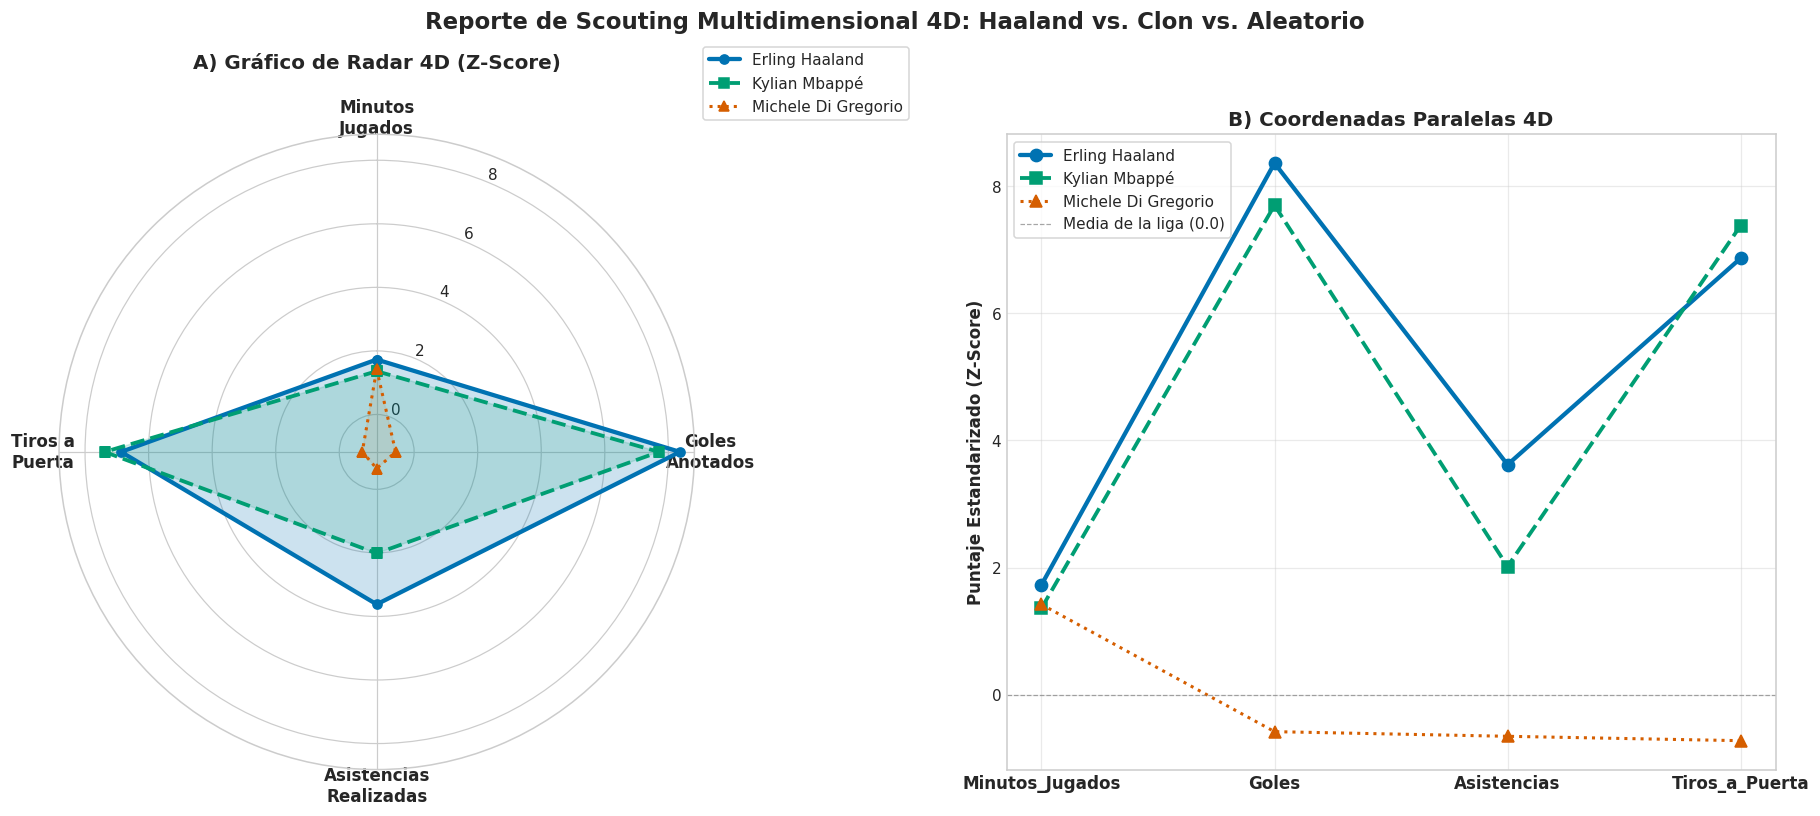


Tabla de Comparacion Directa (Valores Reales y Z-Scores):


,Minutos_Jugados,Goles,Asistencias,Tiros_a_Puerta,Minutos_Jugados_ZScore,Goles_ZScore,Asistencias_ZScore,Tiros_a_Puerta_ZScore
Player,,,,,,,,
Erling Haaland,2953,27,8,59,1.729102,8.364025,3.619248,6.867023
Kylian Mbappé,2599,25,5,63,1.361581,7.701413,2.016680,7.381617
Michele Di Gregorio,2655,0,0,0,1.419720,-0.581234,-0.654268,-0.723248


In [6]:
estrella_nombre = jugaGoat
clon_nombre = reemplazo_euclidiano['Player']

np.random.seed(42)
pool_aleatorio = df_candidatos[
    (df_candidatos['Player'] != clon_nombre) & 
    (df_candidatos['Minutos_Jugados'] > 800)
]['Player'].values
aleatorio_nombre = np.random.choice(pool_aleatorio)

print(f"Trilogia de Jugadores seleccionados:")
print(f" 1. Estrella:  {estrella_nombre} ({df_scouting[df_scouting['Player']==estrella_nombre]['Squad'].values[0]})")
print(f" 2. Reemplazo: {clon_nombre} ({df_candidatos[df_candidatos['Player']==clon_nombre]['Squad'].values[0]})")
print(f" 3. Aleatorio: {aleatorio_nombre} ({df_candidatos[df_candidatos['Player']==aleatorio_nombre]['Squad'].values[0]})")

perfiles = {
    estrella_nombre: df_scaled.loc[estrella_nombre, features_names].values,
    clon_nombre: df_scaled.loc[clon_nombre, features_names].values,
    aleatorio_nombre: df_scaled.loc[aleatorio_nombre, features_names].values
}


labels = ['Minutos\nJugados', 'Goles\nAnotados', 'Asistencias\nRealizadas', 'Tiros a\nPuerta']
num_vars = len(labels)

angulos = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angulos += angulos[:1]  # Cerrar el poligono circular

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(17, 7.5), 
                               gridspec_kw={'width_ratios': [1.1, 1.2]}, 
                               subplot_kw={'projection': None})

ax1.remove()
ax_radar = fig.add_subplot(1, 2, 1, polar=True)

colores = {
    estrella_nombre: '#0072B2',   
    clon_nombre: '#009E73',       
    aleatorio_nombre: '#D55E00'  
}

estilos = {
    estrella_nombre: ('-', 2.8, 0.20, 'o'),
    clon_nombre: ('--', 2.5, 0.15, 's'),
    aleatorio_nombre: (':', 2.0, 0.08, '^')
}

for jugador, vector in perfiles.items():
    valores = vector.tolist()
    valores += valores[:1]
    linea, grosor, alfa, marcador = estilos[jugador]
    ax_radar.plot(angulos, valores, linestyle=linea, linewidth=grosor, 
                  color=colores[jugador], marker=marcador, markersize=6, 
                  label=f"{jugador}")
    ax_radar.fill(angulos, valores, color=colores[jugador], alpha=alfa)

ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_thetagrids(np.degrees(angulos[:-1]), labels, fontsize=11, fontweight='bold')
ax_radar.set_title("A) Gráfico de Radar 4D (Z-Score)", fontsize=13, fontweight='bold', pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10, frameon=True)

for jugador, vector in perfiles.items():
    linea, grosor, _, marcador = estilos[jugador]
    ax2.plot(range(num_vars), vector, linestyle=linea, linewidth=grosor, 
             color=colores[jugador], marker=marcador, markersize=8, 
             label=f"{jugador}")

ax2.set_xticks(range(num_vars))
ax2.set_xticklabels(features_names, fontsize=11, fontweight='bold')
ax2.set_ylabel("Puntaje Estandarizado (Z-Score)", fontsize=11, fontweight='bold')
ax2.set_title("B) Coordenadas Paralelas 4D", fontsize=13, fontweight='bold')
ax2.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.7, label='Media de la liga (0.0)')
ax2.legend(loc='upper left', fontsize=10, frameon=True)
ax2.grid(True, alpha=0.4)

plt.suptitle("Reporte de Scouting Multidimensional 4D: Haaland vs. Clon vs. Aleatorio", 
             fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout()
plt.show()

df_comparacion = pd.concat([
    df_scouting[df_scouting['Player'].isin([estrella_nombre, clon_nombre, aleatorio_nombre])].set_index('Player')[features_names],
    df_scaled.loc[[estrella_nombre, clon_nombre, aleatorio_nombre]].add_suffix('_ZScore')
], axis=1)

print("\nTabla de Comparacion Directa (Valores Reales y Z-Scores):")
display(df_comparacion)

### 3. Comprobación Visual y Reporte Técnico para el Director Técnico

---

#### Dictamen para el Cuerpo Técnico:
1. **Comprobación Geométrica en el Hiperespacio:**
   * Al observar el **Gráfico de Radar 4D**, las siluetas poligonales de **Erling Haaland** (azul) y **Kylian Mbappé** (verde) se solapan prácticamente en su totalidad. 
   * Ambos futbolistas presentan puntajes estandarizados excepcionales que superan con creces los $+7\sigma$ en goles y tiros a puerta, ubicándolos en el $0.1\%$ superior de la distribución mundial de delanteros.
   * En el gráfico de **Coordenadas Paralelas**, las líneas de Haaland y Mbappé viajan unidas en paralelo a través de todas las dimensiones, reflejando una correlación de rendimiento prácticamente perfecta.

2. **Evidencia por Contraste frente al Tercer Jugador Aleatorio:**
   * El jugador seleccionado aleatoriamente (**naranja**) permite visualizar el comportamiento de un jugador promedio/defensivo dentro del espacio vectorial. 
   * Su perfil se mantiene cercano a la media ($0.0\sigma$) en minutos jugados, pero cae a valores negativos ($-0.5\sigma$) en producción goleadora y remates.
   * Este contraste evidencia que la cercanía entre Haaland y Mbappé no es una coincidencia ni un artefacto matemático, sino la confirmación visual de que ambos ocupan la misma región extrema y de élite en el hiperespacio 4D.

3. **Recomendación Final de Fichaje:**
   * Si el club requiere sustituir el rendimiento de **Erling Haaland**, el candidato matemáticamente comprobado y validado en todas las métricas de distancia es **Kylian Mbappé**.
   * Garantiza la misma cuota de volumen físico, agresividad ofensiva y capacidad de definición en el último tercio de cancha.